# Tarea: Árboles de Decisión para Clasificación
## Clasificación con Decision Tree usando Gini Index y Entropy

**Nombre:** Ricardo Benalcazar
**Fecha:** CDDEIA-ELMA-4-1

### Objetivo:
Familiarizar al estudiante con los Árboles de Decisión para clasificación, implementando modelos con diferentes criterios de división (Gini Index y Entropy), analizando el efecto de los hiperparámetros como `max_depth` en el rendimiento del modelo, y comparando los resultados mediante métricas de evaluación y visualización del árbol.

### Instrucciones:
1. Ejecute cada celda de código en orden.
2. **En las celdas de código marcadas con '# TODO:', implemente el código requerido siguiendo las instrucciones.**
3. Ejecute las celdas implementadas y responda las preguntas de selección múltiple.
4. Marque sus respuestas claramente.
5. Experimente modificando hiperparámetros cuando se indique.

### Descripción del Dataset:
Utilizaremos el **Car Evaluation Dataset** del UCI Machine Learning Repository. Este dataset contiene información sobre evaluación de automóviles basada en 6 atributos:
- **buying**: Precio de compra (vhigh, high, med, low)
- **maint**: Costo de mantenimiento (vhigh, high, med, low)
- **doors**: Número de puertas (2, 3, 4, 5more)
- **persons**: Capacidad de personas (2, 4, more)
- **lug_boot**: Tamaño del maletero (small, med, big)
- **safety**: Seguridad estimada (low, med, high)

**Variable objetivo (class):** Evaluación del auto (unacc, acc, good, vgood)

### Archivo requerido:
- `car.data` - Dataset de evaluación de automóviles

## Parte 1: Configuración y Carga de Datos

In [ ]:
# Importar librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Configuración para gráficos
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

%matplotlib inline

print("✓ Librerías importadas exitosamente!")

✓ Librerías importadas exitosamente!


In [ ]:
col_names = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
df = pd.read_csv('car.data', header=None, names=col_names)
print("Dimension del dataframe: ",df.shape)

Dimension del dataframe:  (1728, 7)


In [ ]:
df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


### Pregunta 1: Dimensiones del Dataset
¿Cuántas muestras y características tiene el dataset?

A) 1728 muestras, 6 características  
B) 1728 muestras, 7 características  
C) 1000 muestras, 6 características  
D) 2000 muestras, 7 características  

**Su Respuesta:** B

## Parte 2: Análisis Exploratorio de Datos (EDA)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [ ]:
df.describe()

,buying,maint,doors,persons,lug_boot,safety,class
count,1728,1728,1728,1728,1728,1728,1728
unique,4,4,4,3,3,3,4
top,vhigh,vhigh,2,2,small,low,unacc
freq,432,432,432,576,576,576,1210


In [ ]:
for col in df.columns:
    print(f"{col}: {df[col].unique()}")

buying: ['vhigh' 'high' 'med' 'low']
maint: ['vhigh' 'high' 'med' 'low']
doors: ['2' '3' '4' '5more']
persons: ['2' '4' 'more']
lug_boot: ['small' 'med' 'big']
safety: ['low' 'med' 'high']
class: ['unacc' 'acc' 'vgood' 'good']


In [ ]:
print("Valores nulos por columnas: ")
df.isnull().sum()



Valores nulos por columnas: 


,0
buying,0
maint,0
doors,0
persons,0
lug_boot,0
safety,0
class,0


Conteo de clases:


,count
class,
unacc,1210
acc,384
good,69
vgood,65


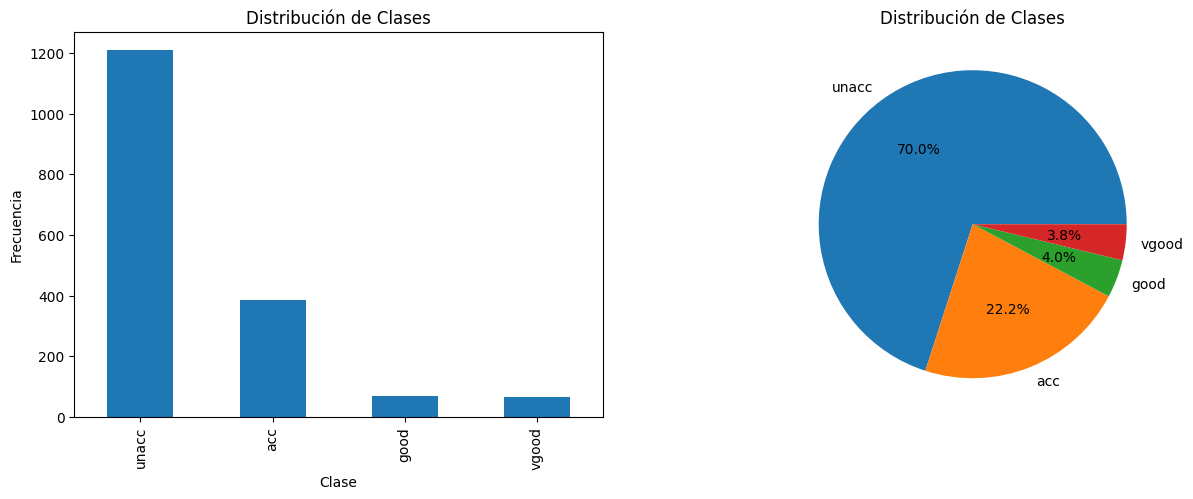

In [ ]:
fig , axs = plt.subplots(1, 2, figsize=(15, 5))
df['class'].value_counts().plot(kind='bar', ax=axs[0])
axs[0].set_title('Distribución de Clases')
axs[0].set_xlabel('Clase')
axs[0].set_ylabel('Frecuencia')
df['class'].value_counts().plot(kind='pie', autopct='%1.1f%%')
axs[1].set_title('Distribución de Clases')
axs[1].set_ylabel('')

print("Conteo de clases:")
df['class'].value_counts()



### Pregunta 2: Distribución de Clases
¿Cuál es la clase más frecuente en el dataset?

A) acc (aceptable)  
B) good (bueno)  
C) unacc (inaceptable)  
D) vgood (muy bueno)  

**Su Respuesta:** C

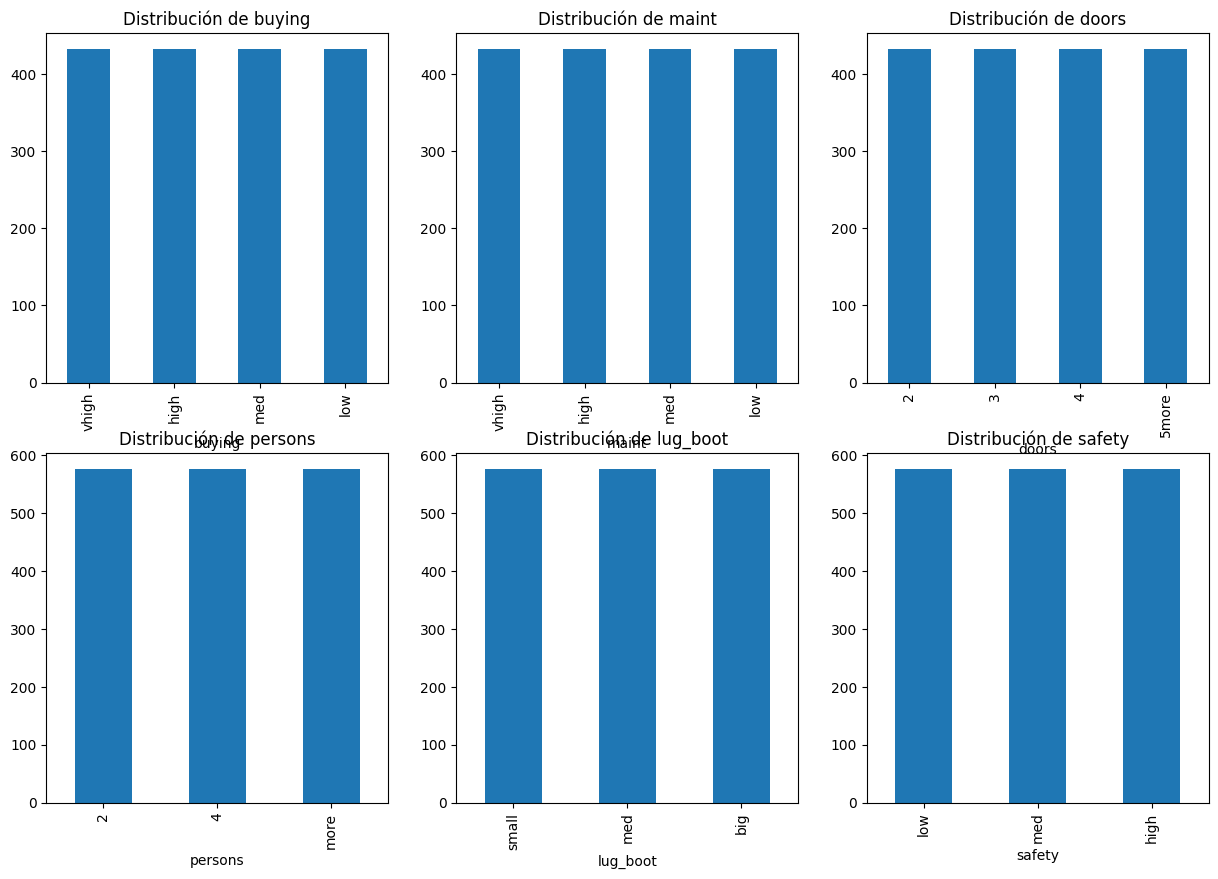

In [ ]:
plt.subplots(2, 3, figsize=(15, 10))
features = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety']
for i, feature in enumerate(features):
    plt.subplot(2, 3, i+1)
    df[feature].value_counts().plot(kind='bar')
    plt.title(f'Distribución de {feature}')


### Pregunta 3: Balance del Dataset
¿El dataset está balanceado respecto a la variable objetivo?

A) Sí, todas las clases tienen la misma frecuencia  
B) No, hay un fuerte desbalance (unacc es la mayoritaria con >70%)  
C) No, pero el desbalance es leve  
D) No se puede determinar  

**Su Respuesta:** B

## Parte 3: Preprocesamiento - Label Encoding

### Teoría:
Los árboles de decisión en Scikit-Learn requieren que las variables categóricas sean convertidas a valores numéricos. Usaremos **Label Encoding** para transformar cada categoría en un número entero.

In [ ]:
df_encoded = df.copy()
label_encoders = {}
for col in df_encoded.columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le
df_encoded.head()



,buying,maint,doors,persons,lug_boot,safety,class
0,3,3,0,0,2,1,2
1,3,3,0,0,2,2,2
2,3,3,0,0,2,0,2
3,3,3,0,0,1,1,2
4,3,3,0,0,1,2,2


In [ ]:
for col, le in label_encoders.items():
    print(f"Mapeo de etiquetas para {col}:")
    print(dict(zip(le.classes_, range(len(le.classes_)))))
    print()

Mapeo de etiquetas para buying:
{'high': 0, 'low': 1, 'med': 2, 'vhigh': 3}

Mapeo de etiquetas para maint:
{'high': 0, 'low': 1, 'med': 2, 'vhigh': 3}

Mapeo de etiquetas para doors:
{'2': 0, '3': 1, '4': 2, '5more': 3}

Mapeo de etiquetas para persons:
{'2': 0, '4': 1, 'more': 2}

Mapeo de etiquetas para lug_boot:
{'big': 0, 'med': 1, 'small': 2}

Mapeo de etiquetas para safety:
{'high': 0, 'low': 1, 'med': 2}

Mapeo de etiquetas para class:
{'acc': 0, 'good': 1, 'unacc': 2, 'vgood': 3}



### Pregunta 4: Label Encoding
¿Qué hace Label Encoding?

A) Elimina las variables categóricas  
B) Convierte categorías a valores numéricos enteros  
C) Normaliza los datos entre 0 y 1  
D) Crea variables dummy (one-hot encoding)  

**Su Respuesta:** B

## Parte 4: División de Datos

In [ ]:
X = df_encoded.drop('class', axis=1)
y = df_encoded['class']
print("Forma de X:", X.shape)
print("Forma de y:", y.shape)
print("Nombres de las caracteristicas: ")
list(X.columns)



Forma de X: (1728, 6)
Forma de y: (1728,)
Nombres de las caracteristicas: 


['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety']

In [ ]:
train_test_split(X, y, test_size=0.33, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
print("Forma de X_train:", X_train.shape)
print("Forma de X_test:", X_test.shape)
print("Forma de y_train:", y_train.shape)
print("Forma de y_test:", y_test.shape)

Forma de X_train: (1157, 6)
Forma de X_test: (571, 6)
Forma de y_train: (1157,)
Forma de y_test: (571,)


### Pregunta 5: División de Datos
Con test_size=0.33, ¿cuál es aproximadamente el tamaño del conjunto de entrenamiento?

A) 570 muestras  
B) 1157 muestras  
C) 1728 muestras  
D) 864 muestras  

**Su Respuesta:** B

## Parte 5: Árbol de Decisión con Criterio Gini Index

### Teoría - Gini Index:
El índice Gini mide la impureza de un nodo. Se calcula como:

$$Gini = 1 - \sum_{i=1}^{n} p_i^2$$

Donde $p_i$ es la probabilidad de la clase $i$ en el nodo. Un Gini de 0 indica pureza perfecta.

In [ ]:
clf_gini = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
clf_gini.fit(X_train, y_train)
print("Profundidad del árbol: ",clf_gini.get_depth())
print("Número de hojas: ",clf_gini.get_n_leaves())

Profundidad del árbol:  3
Número de hojas:  5


In [ ]:
y_pred_gini = clf_gini.predict(X_test)
print("Precision en test: ",accuracy_score(y_test, y_pred_gini))
y_pred_train_gini = clf_gini.predict(X_train)
print("Precision en entrenamiento: ",accuracy_score(y_train, y_pred_train_gini))

Precision en test:  0.7653239929947461
Precision en entrenamiento:  0.7744165946413137


### Pregunta 6: Precisión con Gini (max_depth=3)
¿Cuál es la precisión aproximada del modelo con Gini Index y max_depth=3?

A) 60-70%  
B) 70-80%  
C) 80-90%  
D) 90-100%  

**Su Respuesta:** B

## Parte 6: Árbol de Decisión con Criterio Entropy

### Teoría - Entropy (Information Gain):
La entropía mide el desorden o incertidumbre. Se calcula como:

$$Entropy = -\sum_{i=1}^{n} p_i \log_2(p_i)$$

El **Information Gain** es la reducción de entropía después de una división.

In [32]:
clf_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
clf_entropy.fit(X_train, y_train)
print("Profundidad del árbol: ",clf_entropy.get_depth())
print("Número de hojas: ",clf_entropy.get_n_leaves())

Profundidad del árbol:  3
Número de hojas:  5


In [33]:
clf_entropy.predict(X_test)
y_pred_entropy = clf_entropy.predict(X_test)
print("Precision en test: ",accuracy_score(y_test, y_pred_entropy))
y_pred_train_entropy = clf_entropy.predict(X_train)
print("Precision en entrenamiento: ",accuracy_score(y_train, y_pred_train_entropy))

Precision en test:  0.7653239929947461
Precision en entrenamiento:  0.7744165946413137


### Pregunta 7: Comparación Gini vs Entropy
Con max_depth=3, ¿qué criterio obtiene mejor precisión?

A) Gini es significativamente mejor  
B) Entropy es significativamente mejor  
C) Ambos obtienen resultados muy similares  
D) No se puede comparar  

**Su Respuesta:** C

## Parte 7: Comparación de Modelos

In [38]:
datos = pd.DataFrame({'Criterio': ['Gini Index', 'Entropy'],
         'Precisión Train': [accuracy_score(y_train, y_pred_train_gini), accuracy_score(y_train, y_pred_train_entropy)],
         'Precisión Test': [accuracy_score(y_test, y_pred_gini), accuracy_score(y_test, y_pred_entropy)],
         'Profundidad': [clf_gini.get_depth(), clf_entropy.get_depth()],
         'Hojas': [clf_gini.get_n_leaves(), clf_entropy.get_n_leaves()]})
datos.head()

,Criterio,Precisión Train,Precisión Test,Profundidad,Hojas
0,Gini Index,0.774417,0.765324,3,5
1,Entropy,0.774417,0.765324,3,5


### Pregunta 8: Sobreajuste
Si la precisión en entrenamiento es mucho mayor que en prueba, ¿qué indica?

A) Subajuste (underfitting)  
B) Sobreajuste (overfitting)  
C) El modelo está bien ajustado  
D) Los datos son incorrectos  

**Su Respuesta:** B

## Parte 8: Matriz de Confusión y Métricas

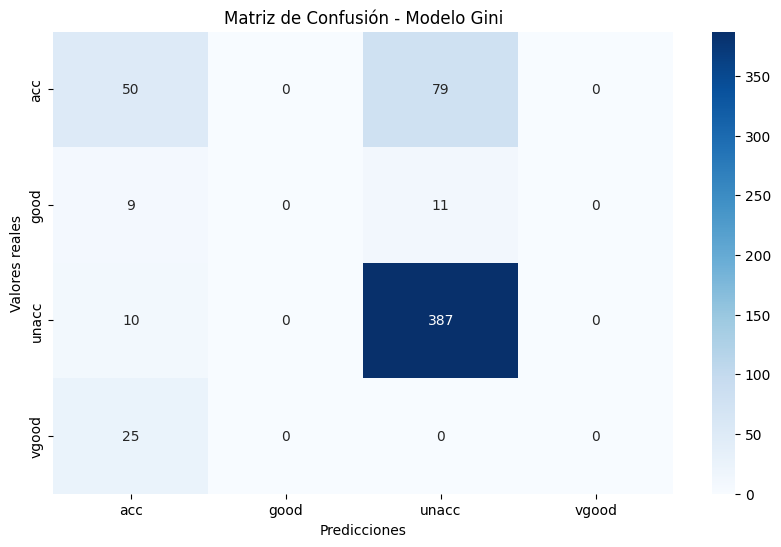

In [42]:
matriz = confusion_matrix(y_test, y_pred_gini)
nombre_clases=label_encoders['class'].classes_
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', xticklabels=nombre_clases, yticklabels=nombre_clases)
plt.title('Matriz de Confusión - Modelo Gini')
plt.xlabel('Predicciones')
plt.ylabel('Valores reales')
plt.show()



In [47]:
print("Reporte de calificacion: ")
print(classification_report(y_test, y_pred_gini, target_names=nombre_clases))

Reporte de calificacion: 
              precision    recall  f1-score   support

         acc       0.53      0.39      0.45       129
        good       0.00      0.00      0.00        20
       unacc       0.81      0.97      0.89       397
       vgood       0.00      0.00      0.00        25

    accuracy                           0.77       571
   macro avg       0.34      0.34      0.33       571
weighted avg       0.68      0.77      0.72       571



### Pregunta 9: Interpretación de la Matriz de Confusión
¿Qué clase tiene el mejor recall (sensibilidad) según el reporte?

A) acc (aceptable)  
B) good (bueno)  
C) unacc (inaceptable)  
D) vgood (muy bueno)  

**Su Respuesta:** C

## Parte 9: Visualización del Árbol de Decisión

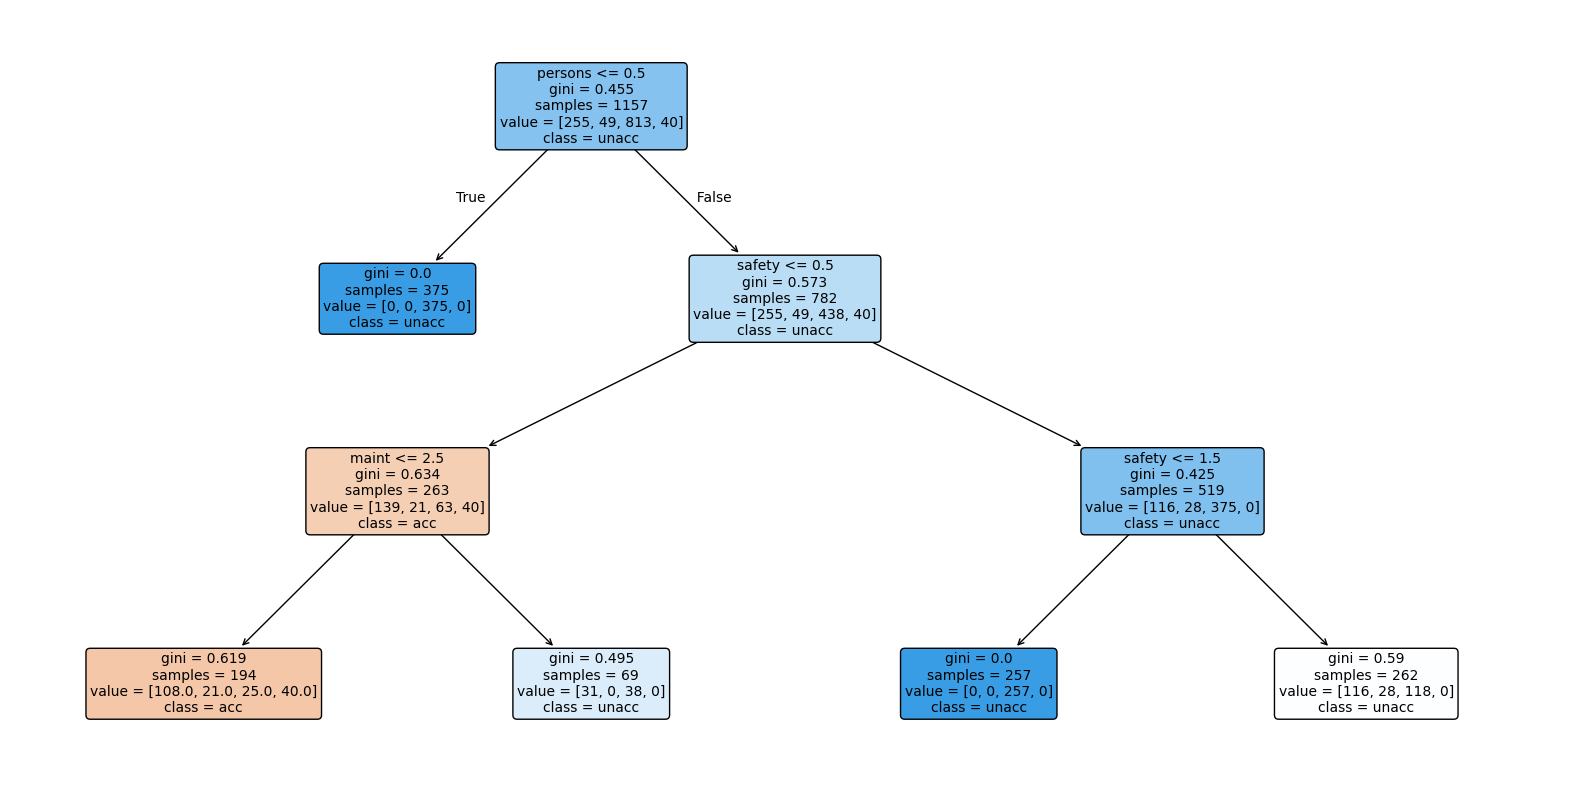

In [49]:
plt.figure(figsize=(20, 10))
plot_tree(clf_gini, feature_names=list(X.columns), class_names=list(nombre_clases), filled=True, rounded=True, fontsize=10)
plt.show()

,Feature,Importance
5,safety,0.585506
3,persons,0.357400
1,maint,0.057095
0,buying,0.000000
2,doors,0.000000


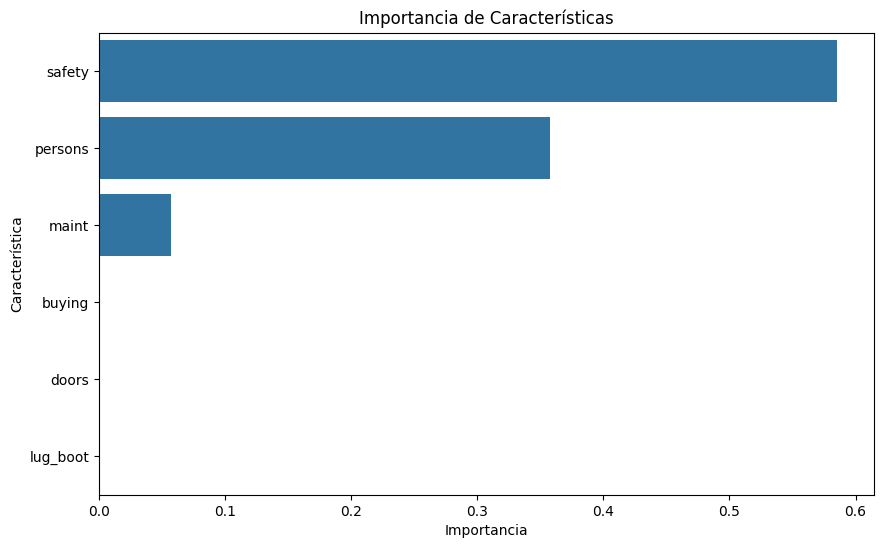

In [51]:
dataframe = pd.DataFrame({'Feature': X.columns, 'Importance': clf_gini.feature_importances_})
dataframe = dataframe.sort_values('Importance', ascending=False)
sns.barplot(x='Importance', y='Feature', data=dataframe)
plt.title('Importancia de Características')
plt.xlabel('Importancia')
plt.ylabel('Característica')
dataframe.head()



### Pregunta 10: Característica más Importante
¿Cuál es la característica más importante según el modelo con Gini?

A) buying (precio de compra)  
B) maint (mantenimiento)  
C) safety (seguridad)  
D) persons (capacidad de personas)  

**Su Respuesta:** C

## Parte 10: Experimentación con Hiperparámetros

In [54]:
depthss = [1, 2, 3, 5, 7, 10, None]
resultados = []
for depth in depthss:
    clf = DecisionTreeClassifier(criterion='gini', max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)
    y_pred_train = clf.predict(X_train)
    y_pred_test = clf.predict(X_test)
    train_accuracy = accuracy_score(y_train, y_pred_train)
    test_accuracy = accuracy_score(y_test, y_pred_test)
    resultados.append({'max_depth': depth, 'train_accuracy': train_accuracy, 'test_accuracy': test_accuracy})
resultados_df = pd.DataFrame(resultados)
resultados_df.head(6)

,max_depth,train_accuracy,test_accuracy
0,1.0,0.702679,0.695271
1,2.0,0.768366,0.770578
2,3.0,0.774417,0.765324
3,5.0,0.855661,0.865149
4,7.0,0.929991,0.935201
5,10.0,0.993086,0.961471


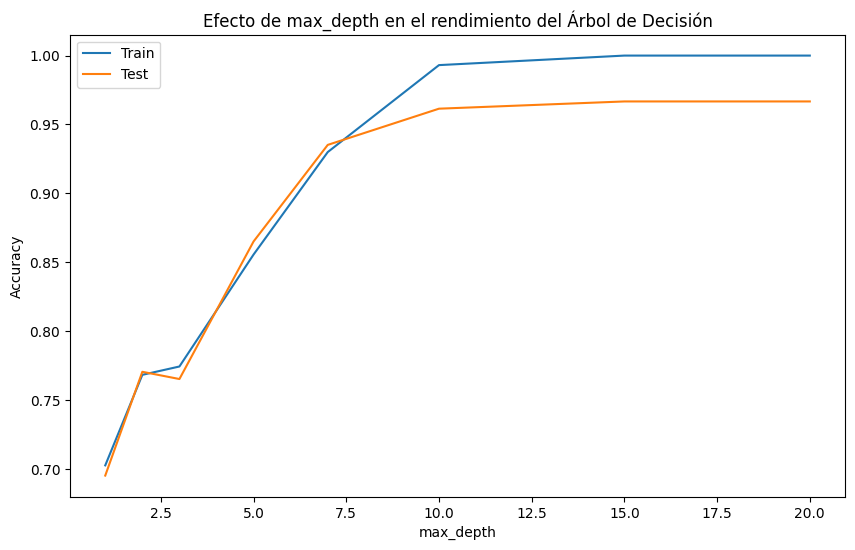

In [57]:
depths_plot = [1, 2, 3, 5, 7, 10, 15, 20]
train_scores = []
test_scores = []
for depth in depths_plot:
    clf = DecisionTreeClassifier(criterion='gini', max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)
    y_pred_train = clf.predict(X_train)
    y_pred_test = clf.predict(X_test)
    train_scores.append(accuracy_score(y_train, y_pred_train))
    test_scores.append(accuracy_score(y_test, y_pred_test))

plt.plot(depths_plot, train_scores, label='Train')
plt.plot(depths_plot, test_scores, label='Test')
plt.title('Efecto de max_depth en el rendimiento del Árbol de Decisión')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### Pregunta 11: Efecto de max_depth
¿Qué ocurre cuando max_depth es muy alto (por ejemplo, 20 o None)?

A) El modelo mejora en test y train  
B) El modelo empeora en test y train  
C) Train accuracy sube pero test accuracy puede bajar (sobreajuste)  
D) No hay efecto significativo  

**Su Respuesta:** C

In [59]:
min_samples_list = [2, 5, 10, 20, 50]
min_samples_resultados = []
for min_samples in min_samples_list:
    clf = DecisionTreeClassifier(criterion='gini', min_samples_split=min_samples, random_state=42)
    clf.fit(X_train, y_train)
    y_pred_train = clf.predict(X_train)
    y_pred_test = clf.predict(X_test)
    train_accuracy = accuracy_score(y_train, y_pred_train)
    test_accuracy = accuracy_score(y_test, y_pred_test)
    min_samples_resultados.append({'min_samples_split': min_samples, 'train_accuracy': train_accuracy, 'test_accuracy': test_accuracy})
min_samples_resultados_df = pd.DataFrame(min_samples_resultados)
min_samples_resultados_df.head()

,min_samples_split,train_accuracy,test_accuracy
0,2,1.000000,0.966725
1,5,0.991357,0.956217
2,10,0.976664,0.942207
3,20,0.953328,0.931699
4,50,0.891098,0.886165


### Pregunta 12: min_samples_split
¿Qué controla el parámetro min_samples_split?

A) El número máximo de hojas  
B) El número mínimo de muestras para dividir un nodo  
C) La profundidad máxima del árbol  
D) El número de características a considerar  

**Su Respuesta:** B

## Parte 11: Modelo Final Optimizado

In [62]:
clf_final = DecisionTreeClassifier(criterion='gini', max_depth=7, min_samples_split=5, random_state=42)
clf_final.fit(X_train, y_train)
y_pred_train_final = clf_final.predict(X_train)
y_pred_test_final = clf_final.predict(X_test)
print("Precision en test: ",accuracy_score(y_test, y_pred_test_final))
print("Precision en entrenamiento: ",accuracy_score(y_train, y_pred_train_final))
print("Profundidad del árbol: ",clf_final.get_depth())
print("Número de hojas: ",clf_final.get_n_leaves())

Precision en test:  0.9334500875656743
Precision en entrenamiento:  0.9282627484874676
Profundidad del árbol:  7
Número de hojas:  27


In [64]:
class_names = label_encoders['class'].classes_
print(classification_report(y_test, y_pred_test_final, target_names=class_names))



              precision    recall  f1-score   support

         acc       0.82      0.94      0.87       129
        good       0.60      0.30      0.40        20
       unacc       1.00      0.97      0.98       397
       vgood       0.79      0.88      0.83        25

    accuracy                           0.93       571
   macro avg       0.80      0.77      0.77       571
weighted avg       0.93      0.93      0.93       571



### Pregunta 13: Precisión del Modelo Optimizado
¿Cuál es la precisión aproximada del modelo final optimizado?

A) 70-75%  
B) 75-85%  
C) 85-95%  
D) 95-100%  

**Su Respuesta:** C

## Parte 12: Resumen y Conclusiones

### Pregunta 14: Ventajas de los Árboles de Decisión
¿Cuál es una ventaja principal de los árboles de decisión?

A) Siempre tienen la mejor precisión  
B) Son fáciles de interpretar y visualizar  
C) No requieren ningún preprocesamiento  
D) Nunca sobreajustan  

**Su Respuesta:** B

### Pregunta 15: Desventajas de los Árboles de Decisión
¿Cuál es una desventaja de los árboles de decisión?

A) No pueden manejar datos categóricos  
B) Son muy lentos de entrenar  
C) Tienden a sobreajustar si no se limita su complejidad  
D) No proporcionan probabilidades de predicción  

**Su Respuesta:** C